In [1]:
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from pathlib import Path
import sys
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
print("Project root path:", project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.fuelcell import PEMFC_1D
from model.coefficients import *
from configuration.initialize import *


Project root path: d:\MFC2024


In [2]:
Hcl, Hgdl, Hmem = parameters['Hcl'], parameters['Hgdl'], parameters['Hmem']
Lgc, Wgc, Hgc = parameters['Lgc'], parameters['Wgc'], parameters['Hgc']

In [3]:
Phi_a_des, Phi_c_des, Tfc = operating_inputs['Phi_a_des'], operating_inputs['Phi_c_des'], operating_inputs['Tfc']
Pa_des, Pc_des = operating_inputs['Pa_des'], operating_inputs['Pc_des']
Win_c, Wout_c = operating_inputs['Win_c'], operating_inputs['Wout_c']
Win_a, Wout_a = operating_inputs['Win_a'], operating_inputs['Wout_a']

i = 1.2e4 # current density (A/m^2)

In [4]:
### Define the water flow at CCL
Srxn = i / (2 * F) # mol/s/m^2
### Water inlet
Cv_in_a = Phi_a_des * Csat(Tfc)
Cv_in_c = Phi_c_des * Csat(Tfc)

In [ ]:
Jnet = 0
### First define the water flow at the cathode
Jw_ca = Srxn
Jw_an = 0
### First solve the gdl vapor profile
Cv_cgc = (Jw_ca * parameters["Lgc"] / parameters["Hgc"] + Cv_in_c * Win_c)/Wout_c
Cv_agc = (Jw_an * parameters["Lgc"] / parameters["Hgc"] + Cv_in_a * Win_a)/Wout_a
Cv_a_inter = Cv_agc + Jw_an/h_conv(Pa_des, Tfc, parameters["Wgc"], parameters["Hgc"])
Cv_acl = Cv_a_inter + Hgdl/Dc(Pa_des, Tfc) * Jw_an
Cv_c_inter = Cv_cgc + Jw_ca/h_conv(Pc_des, Tfc, parameters["Wgc"], parameters["Hgc"])
Cv_ccl = Cv_c_inter - Hgdl/Dc(Pc_des, Tfc) * -Jw_ca

    # determine the front position of the saturation in GDL
if Cv_ccl > Csat(Tfc) and Cv_cgc < Csat(Tfc):
    rhs = (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5)
    s_front_cgdl = 0.35425 *0 ** 4 - 0.848 *  0**5 + 0.6315 *  0 ** 6 * rhs / (M_H2O * Jw_ca)
elif Cv_cgc > Csat(Tfc) and Cv_ccl > Csat(Tfc):
    s_front_cgdl = Hgdl
else:
    s_front_cgdl = 0
if Cv_acl > Csat(Tfc) and Cv_agc < Csat(Tfc):
    s_front_agdl = (Csat(Tfc) - Cv_a_inter) * (Dc(Pa_des, Tfc) / Jw_an)
elif Cv_agc > Csat(Tfc) and Cv_acl > Csat(Tfc):
    s_front_agdl = 0
else:
    s_front_agdl = Hgdl

# GDL profile
s_cgdl = np.zeros(10)
s_agdl = np.zeros(10)
Cv_cgdl = np.zeros(10)
Cv_agdl = np.zeros(10)
i_node = 0
for x in np.linspace(0, Hgdl, 10):
    # CGDL saturation profile
    rhs = (M_H2O * Jw_ca * (x)) / (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5)
    def s_cgdl_func(n):
        return 0.35425 * n ** 4 - 0.848 * n **5 + 0.6315 * n ** 6 - rhs
    if x < s_front_cgdl:
        solution = fsolve(s_cgdl_func, x0=s_front_cgdl)
    else:
        solution = [0]
    s_cgdl[i_node] = solution[0]
    # AGDL saturation profile
    rhs = (M_H2O * Jw_an * (s_front_agdl-x)) / (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5)
    def s_agdl_func(n):
        return 0.35425 * n ** 4 - 0.848 * n **5 + 0.6315 * n ** 6 - rhs
    if x > s_front_agdl:
        solution = fsolve(s_agdl_func, x0=s_front_agdl)
    else:
        solution = [0]
    s_agdl[i_node] = solution[0]
    # Vapor concentration profile
    Cv_cgdl[i_node] = Cv_c_inter + (Hgdl-x)/Dc(Pc_des, Tfc) * Jw_ca
    Cv_agdl[i_node] = Cv_a_inter + (Hgdl-x)/Dc(Pa_des, Tfc) * Jw_an
    i_node += 1

# Water content
if Cv_ccl > Csat(Tfc):
    lambda_ccl = np.min([14 + 8*s_cgdl[0], 22])
else:
    lambda_ccl = np.min([lambda_eq(Cv_ccl, 0, Tfc, 20) + Jw_ca * M_eq / (epsilon_cl * Hcl * 1.3 *rho_mem) , 14])
if Cv_acl > Csat(Tfc):
    lambda_acl = np.min([14 + 8*s_agdl[0], 22])
else:
    lambda_acl = np.min([lambda_eq(Cv_acl, 0, Tfc, 20) + Jw_an * M_eq / (epsilon_cl * Hcl * 1.3 *rho_mem) , 14])

Klambda = rho_mem/M_eq * Dw(lambda_ccl, 333.15) / (2.5/22 * i / F)
lambda_mem = [lambda_ccl * np.exp(x/Klambda) for x in np.linspace(-2e-5, 0, 10)]

Jmem = 2.5/22 * i / F * (lambda_ccl - lambda_acl* np.exp(parameters["Hmem"]/Klambda)) / (np.exp(parameters["Hmem"]/Klambda) - 1)

In [6]:
print("Jmem =", Jmem, ", Jnet =", Jnet)

Jmem = 0.12933739657190366 , Jnet = 0


In [ ]:
while abs(Jnet - Jmem) > 1e-4:

    Jnet += 0.01 * (Jmem - Jnet)**2
    Jw_ca = i / (2 * F) + Jnet
    Jw_an = -Jnet
    
    ### First solve the gdl vapor boundary condition
    Cv_cgc = (Jw_ca * parameters["Lgc"] / parameters["Hgc"] + Cv_in_c * Win_c)/Wout_c
    Cv_agc = (Jw_an * parameters["Lgc"] / parameters["Hgc"] + Cv_in_a * Win_a)/Wout_a
    Cv_a_inter = Cv_agc + Jw_an/h_conv(Pa_des, Tfc, parameters["Wgc"], parameters["Hgc"])
    Cv_c_inter = Cv_cgc + Jw_ca/h_conv(Pc_des, Tfc, parameters["Wgc"], parameters["Hgc"])
    # determine the front position of the saturation in GDL
    if Cv_ccl > Csat(Tfc) and Cv_cgc < Csat(Tfc):
        rhs = (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5)
        s_front_cgdl = 0.35425 * s_cgdl[-1] ** 4 - 0.848 *  s_cgdl[-1] **5 + 0.6315 *  s_cgdl[-1] ** 6 * rhs / (M_H2O * Jw_ca)
    elif Cv_cgc > Csat(Tfc) and Cv_ccl > Csat(Tfc):
        s_front_cgdl = Hgdl
    else:
        s_front_cgdl = 0
    if Cv_acl > Csat(Tfc) and Cv_agc < Csat(Tfc):
        s_front_agdl = (Csat(Tfc) - Cv_a_inter) * (Dc(Pa_des, Tfc) / Jw_an)
    elif Cv_agc > Csat(Tfc) and Cv_acl > Csat(Tfc):
        s_front_agdl = 0
    else:
        s_front_agdl = Hgdl

    Cv_acl = Cv_a_inter + Hgdl/Dc(Pa_des, Tfc) * Jw_an
    Cv_ccl = Cv_c_inter + Hgdl/Dc(Pc_des, Tfc) * -Jw_ca

    # GDL profile
    s_cgdl = np.zeros(10)
    s_agdl = np.zeros(10)
    Cv_cgdl = np.zeros(10)
    Cv_agdl = np.zeros(10)
    i_node = 0
    for x in np.linspace(0, Hgdl, 10):
        # CGDL saturation profile
        rhs = (M_H2O * Jw_ca * (x)) / (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5)
        def s_cgdl_func(n):
            return 0.35425 * n ** 4 - 0.848 * n **5 + 0.6315 * n ** 6 - rhs
        if x < s_front_cgdl:
            solution = fsolve(s_cgdl_func, x0=s_front_cgdl)
        else:
            solution = [0]
        s_cgdl[i_node] = solution[0]
        # AGDL saturation profile
        rhs = (M_H2O * Jw_an * (x)) / (sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5)
        def s_agdl_func(n):
            return 0.35425 * n ** 4 - 0.848 * n **5 + 0.6315 * n ** 6 - rhs
        if x > s_front_agdl:
            solution = fsolve(s_agdl_func, x0=s_front_agdl)
        else:
            solution = [0]
        s_agdl[i_node] = solution[0]
        # Vapor concentration profile
        Cv_cgdl[i_node] = Cv_c_inter + (x)/Dc(Pc_des, Tfc) * Jw_ca
        Cv_agdl[i_node] = Cv_a_inter + (x)/Dc(Pa_des, Tfc) * Jw_an
        i_node += 1

    # Water content
    if Cv_ccl > Csat(Tfc):
        lambda_ccl = np.min([14 + 8*s_cgdl[0], 22])
    else:
        lambda_ccl = np.min([lambda_eq(Cv_ccl, 0, Tfc, 20) + Jw_ca * M_eq / (epsilon_cl * Hcl * 1.3 *rho_mem) , 14])
    if Cv_acl > Csat(Tfc):
        lambda_acl = np.min([14 + 8*s_agdl[0], 22])
    else:
        lambda_acl = np.min([lambda_eq(Cv_acl, 0, Tfc, 20) + Jw_an * M_eq / (epsilon_cl * Hcl * 1.3 *rho_mem) , 14])

    Klambda = rho_mem/M_eq * Dw(lambda_ccl, 333.15) / (2.5/22 * i / F)
    lambda_mem = [lambda_ccl * np.exp(x/Klambda) for x in np.linspace( -2e-5, 0, 10)]

    Jmem = 2.5/22 * i / F * (lambda_acl* np.exp(parameters["Hmem"]/Klambda) - lambda_ccl) / (np.exp(parameters["Hmem"]/Klambda) - 1)

d:\MFC2024\model\coefficients.py:34: RuntimeWarning: overflow encountered in exp
  + 0.5 * (9.2 + 8.6 * (1 - np.exp(-Kshape * (a_w - 1)))) * (1 + np.tanh(100 * (a_w - 1)))
d:\MFC2024\model\coefficients.py:34: RuntimeWarning: invalid value encountered in scalar multiply
  + 0.5 * (9.2 + 8.6 * (1 - np.exp(-Kshape * (a_w - 1)))) * (1 + np.tanh(100 * (a_w - 1)))


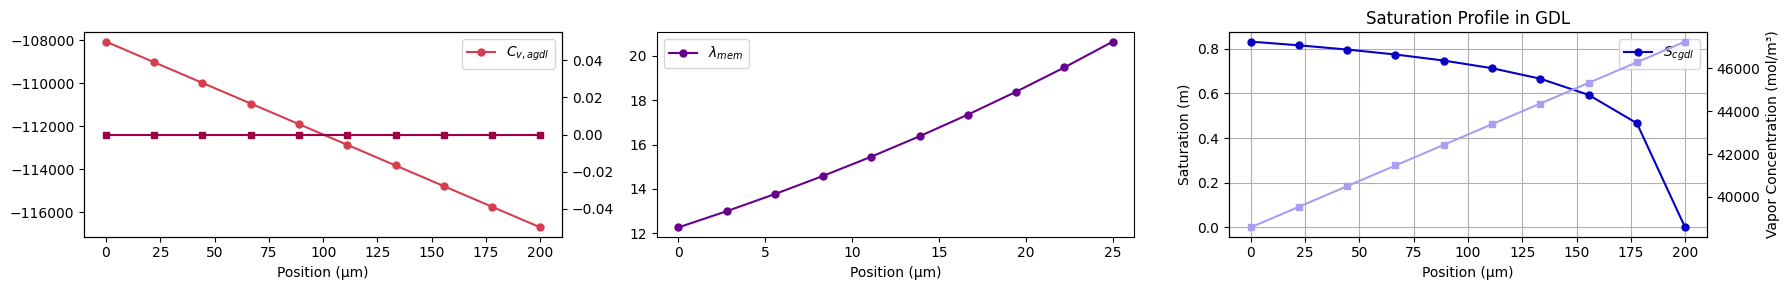

In [8]:
fig, axes = plt.subplots(nrows=1, ncols= 3, figsize=(18, 3))
axes[0].plot(np.linspace(0, Hgdl*1e6, 10), Cv_agdl, marker='o', markersize=5, color = "#d53e4f", label = "$C_{v, agdl}$")
ax2 = axes[0].twinx()
ax2.plot(np.linspace(0, Hgdl*1e6, 10), s_agdl, marker='s', markersize=5, color = "#9e0142", label = "$S_{agdl}$")
axes[0].set_xlabel('Position (µm)')
axes[1].plot(np.linspace(0, parameters["Hmem"]*1e6, 10), lambda_mem, marker='o', markersize=5, color = "#67008d", label = r"$\lambda_{mem}$")
axes[1].set_xlabel('Position (µm)')
axes[2].plot(np.linspace(0, Hgdl*1e6, 10), s_cgdl, marker='o', markersize=5, color = "#0700c5", label = "$S_{cgdl}$")
ax2 = axes[2].twinx()
ax2.plot(np.linspace(0, Hgdl*1e6, 10), Cv_cgdl, marker='s', markersize=5, color = "#aa9ef2", label = "$C_{v, cgdl}$")
axes[2].set_xlabel('Position (µm)')
axes[2].set_ylabel('Saturation (m)')
axes[2].set_title('Saturation Profile in GDL')
axes[2].grid(True)
ax2.set_ylabel('Vapor Concentration (mol/m³)')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()